# Single-cell ATAC-seq data analysis

So far, we have worked with scRNA-seq data which quantifies gene expression at single-cell resolution. As such, it provides information on the transcriptomic level, but what about epigenomics? That is where the single-cell Assay for Transposase-Accessible Chromatin using sequencing (scATAC-seq) comes into play! Specifically, scATAC-seq measures chromatin accessibility by cutting and barcoding open chromatin with Tn5 tagmentation, i.e., the counts in scATAC-seq data come from paired end sequencing, which produces paired associations between reads.

The data generated by scATAC-seq differs fundamentally from scRNA-seq data. Early scATAC-seq work, for example, introduced the idea that scATAC-seq data are more like *categorical* data than continuous-valued expression data since we are not interested in the scale of a feature, but rather whether a given sample expresses that feature. In biological terms, we want to consider not *how accessible* a region is - a biologically meaningless notion here because there are only two copies of each chromosome, so accessibility can only be 0, 1, or 2 - but rather *which regions* are accessible per-cell. While it is conceptually different compared to how we think of and treat scRNA-seq data, there is still a rich theoretical basis and history of research in the context of other well-known data analysis problems. Text-based analysis, for example, traditionally tabulated words or topics appearing in a document to represent it, accompanied by a full body of work on embedding and comparing documents in this way, which we will directly translate to our problem setting.

However, scRNA-seq and scATAC-seq data do not only differ in how we interpret the data: Compared with scRNA-seq analysis: scATAC-seq data is even sparser and noisier, and there are many options for representing the data. As a result, scATAC-seq analysis can be even more complex compared with scRNA-seq data, and there are numerous analysis packages, each making its own decision already starting with the most basic aspects of analysis. To aid in analysing scATAC-seq data <a href="https://www.archrproject.com/">ArchR</a> is one such package, frequently used to perform end-to-end analysis from aligned sequencing reads; running CellRanger ATAC after a 10X experiment provides these reads in either fragment file or bam file format.

In general, ArchR employs the following philosophy as visualized below: ArchR converts fragment files into one or more feature representations of dimension $n_{\text{c}} \times n_{\text{f}}$, where $n_{\text{c}}$ and $n_{\text{f}}$ denote the number of cells and features, respectively. Whereas for scRNA-seq data the canonical data representation, i.e., the count matrix, used genes as features, for scATAC-seq data, features can be so-called tiles - bins in the genome -, peaks of accessibility - a representation of enhancers and promoters -, or even per-gene accessibility scores. Regardless of the feature, the corresponding data matrix is stored in efficient *arrow* files on disk, to which additional outputs are appended as we continue through the pipeline. In conclusion, because of these design choices, ArchR allows us to represent the data in multiple ways; it operates on whichever representation we prefer; and it scales to millions of features, a typical magnitude in ATAC-seq analysis.

<img src="https://www.archrproject.com/bookdown/images/ArchRProject_Schematic.png" alt="genescore" width="800">

For this lab, we will not directly use ArchR, though. Instead, we will work with a pre-processed dataset in the tile representation, i.e., each feature represents the number of Tn5 cuts that occurred in a 500 bp region of the genome; only accessible regions are included; those which are fully compacted will be excluded. Importantly, the data has been pre-filtered to remove low-variability or poor-coverage tiles to ensure that the dataset is a feasible size for our lab. Otherwise, we would work with hundreds of millions of features!

Before we start, we collect and define terms frequently used when working with scATAC data
* **Tile** are bins in the genome.
* **Fragments** are the regions spanned between two associated reads.
* **Peaks** are regions with substantial accessibility.

## Library imports

In [64]:
import matplotlib.pyplot as plt

import scanpy as sc

from qibs2026 import DATA_DIR

## General settings

In [65]:
sc.settings.verbosity = 2
sc.set_figure_params(frameon=False, transparent=True)

## Constants

In [66]:
DATASET_ID = "lab_3"

data_path = "/athena/qibs_class/scratch/jfm4002/qibs2026/data/lab_3/processed"

## Function definitions

## 1. Data loading

As usual, we start by loading our data to analyse. Note that the data already includes some additional information besides the tile representation and basic tile metadata that will become relevant later on; for now, we will simply ignore it.

<div style="padding: 10px; border-radius: 1px; width: 98%">
  <div style="background-color: rgb(83, 83, 83); color: white; padding: 10px; border-radius: 5px 5px 0 0; margin: -10px -10px 10px -10px">
    <b>Exercise 1.1</b>
  </div>
  Use <a href="https://anndata.readthedocs.io/en/latest/">anndata</a> to load the H5AD file <i>adata_filtered_vartiles.h5ad</i>.
</div>

In [67]:
# Implement your solution here
adata = sc.read_h5ad(f"{data_path}/adata_filtered_vartiles.h5ad")

KeyboardInterrupt: 

In [ ]:
adata

AnnData object with n_obs × n_vars = 5531 × 150000
    obs: 'metacell_assignment', 'metacell_center'
    var: 'chr', 'start', 'end'
    obsm: 'gene_score'

## 2. Data overview

<div style="padding: 10px; border-radius: 1px; width: 98%">
  <div style="background-color: rgb(83, 83, 83); color: white; padding: 10px; border-radius: 5px 5px 0 0; margin: -10px -10px 10px -10px">
    <b>Exercise 2.1</b>
  </div>
  Randomly sample 10,000 non-zero entries and visualize the resulting distribution with a histogram.
</div>

<div style="padding: 10px; border-radius: 1px; width: 98%">
  <div style="background-color: rgb(114, 134, 86); color: white; padding: 10px; border-radius: 5px 5px 0 0; margin: -10px -10px 10px -10px">
    <b>Question 2.1</b>
  </div>
  What is the maximum count in the data matrix?
</div>

In [ ]:
# Implement your solution here
import numpy as np

non_zero_values = adata.X[adata.X.nonzero()]
random_sample = np.random.choice(non_zero_values.A1, size=10000, replace=False)

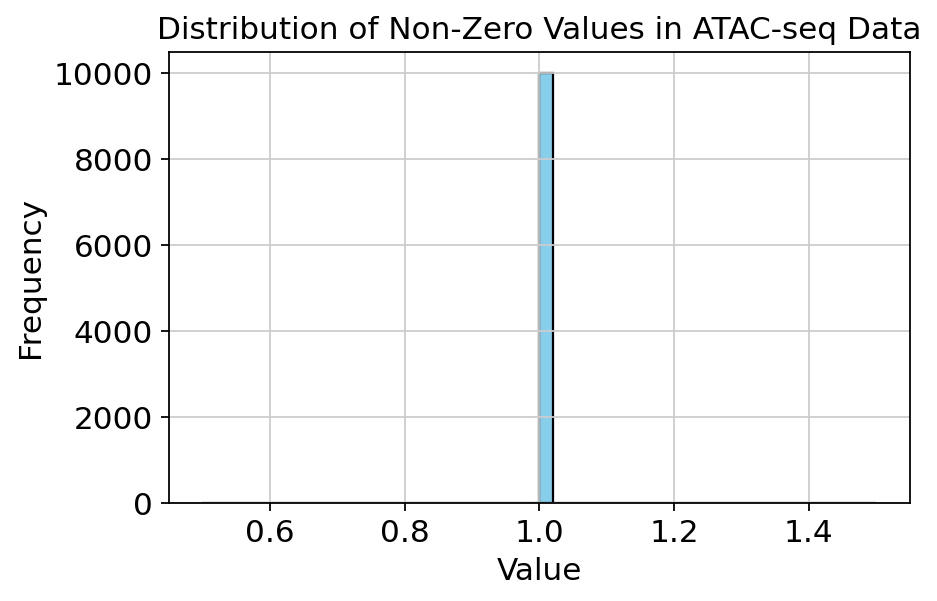

In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(random_sample, bins=50, color="skyblue", edgecolor="black")
ax.set_title("Distribution of Non-Zero Values in ATAC-seq Data")
ax.set_xlabel("Value")
ax.set_ylabel("Frequency")
plt.tight_layout()
plt.show()

In [ ]:
max_value = adata.X.max()
print(f"Maximum value in the ATAC-seq data: {max_value}")

Maximum value in the ATAC-seq data: 1.0


## 3. Quality control metrics

Compared with scRNA-seq analysis, scATAC-seq data have similar but also very different quality control (QC) metrics. ArchR computes relevant QC metrics automatically for us to filter our data based of appropriate thresholds. Here, we will compute some QC metrics from scratch.

**Caveat:** Our data here has been binarized, but, in practice, we compute these metrics on non-binarized data - keep this in mind for real-world analyses!

### Total fragment counts

Among the first QC metrics we computed for scRNA-seq data was the library size and number of cells expressing a gene. Similarly, for scATAC-seq data, we compute the number of fragments per cell and tile, respectively.

<div style="padding: 10px; border-radius: 1px; width: 98%">
  <div style="background-color: rgb(83, 83, 83); color: white; padding: 10px; border-radius: 5px 5px 0 0; margin: -10px -10px 10px -10px">
    <b>Exercise 3.1</b>
  </div>
  <ol type="a">
    <li>Add the number of fragments per cell and their log1p-transformation to the AnnData object using the identifiers <i>n_fragments</i> and <i>log1p_n_fragments</i>.</li>
    <li>Add the number of fragments per tile and their log1p-transformation to the AnnData object using the identifier <i>n_fragments</i> and <i>log1p_n_fragments</i>.</li>
  </ol>
</div>

<div style="padding: 10px; border-radius: 1px; width: 98%">
  <div style="background-color: rgb(114, 134, 86); color: white; padding: 10px; border-radius: 5px 5px 0 0; margin: -10px -10px 10px -10px">
    <b>Question 3.1</b>
  </div>
  What percentage of tiles is accessible in at least 50 cells? Round to two decimals.
</div>

In [ ]:
# Implement your solution here
fragments_per_cell = adata.X.sum(axis=1).A1
log1p_fragments_per_cell = np.log1p(fragments_per_cell)
fragments_per_tile = adata.X.sum(axis=0).A1
log1p_fragments_per_tile = np.log1p(fragments_per_tile) # since data is binarized, this is equal to the amount of cells that tile is accesible in

adata.obs["fragments_per_cell"] = fragments_per_cell
adata.obs["log1p_fragments_per_cell"] = log1p_fragments_per_cell
adata.var["fragments_per_tile"] = fragments_per_tile
adata.var["log1p_fragments_per_tile"] = log1p_fragments_per_tile

In [ ]:
# Calculate the percentage of tiles accessible in at least 50 cells
tiles_accesible_50 = (fragments_per_tile >= 50).sum()
total_tiles = len(fragments_per_tile)
percentage_accesible_50 = (tiles_accesible_50 / total_tiles) * 100
print(f"Percentage of tiles accessible in at least 50 cells: {percentage_accesible_50:.2f}%")

Percentage of tiles accessible in at least 50 cells: 81.45%


### Fragment length

Next, we will study the distribution of fragment lengths. To start and motivate why this distribution is relevant, consider the process that generates these fragments: as tagmentation occurs, each Tn5 cut adds sequencing adapters which mark the end of a read. Thus, the ends of a fragment mark two consecutive cutting events as the corresponding cuts (linearly in the genome) span each fragment.
So how does this fact relate fragment length to region in the genome? In brief,

* **Highly accessibile regions with full access for Tn5:** cutting happens pretty much everywhere, and fragments are short.
* **Nucleosome-bound regions:** the length of each fragment will be longer, as the nucleosomes occlude Tn5 cutting.

This observation holds for both bulk and single-cell ATAC-seq! Now, remembering that nucleosomes wrap a precise length of DNA (roughly 147bp each), we can expect extrema in the fragment length distribution occuring in 147bp-increments and corresponding to the number of nucleosomes that are positioned between consecutive events. It turns out that the existence of this pattern is a good QC metric!

Our count matrix specifies how many cuts occured per tile but not cuts pairs, so we cannot estimate the fragment length distribution from the data at hand. Instead, we have to turn to the raw fragment file that contains the positions of the upstream and downstream cut for each fragment.

<div style="padding: 10px; border-radius: 1px; width: 98%">
  <div style="background-color: rgb(83, 83, 83); color: white; padding: 10px; border-radius: 5px 5px 0 0; margin: -10px -10px 10px -10px">
    <b>Exercise 3.2</b>
  </div>
  Use <a href="https://pandas.pydata.org/">pandas</a> to save the first 50000 rows of the <i>fragments.tsv.gz</i> file, located in <i>data/lab_3/processed</i>, as a DataFrame called <code>fragments</code> with column names <code>chr</code> (the reference chromosome), <code>start</code> (the (adjusted) start position), <code>end</code> (the (adjusted) end position), <code>barcode</code> (10X barcode), and <code>read_support</code> (total number of read pairs).
</div>

In [ ]:
# Implement your solution here
import pandas as pd

fragments = pd.read_csv(f"{data_path}/fragments.tsv.gz", nrows=50000, sep="\t", header=None)
fragments.columns = ["chr", "start", "end", "barcode", "read_support"]
fragments

,chr,start,end,barcode,read_support
0,chr1,10059,10120,ATTACTCTCCCGTAGG-1,9
1,chr1,10059,10132,AAGGAGCAGAGCACTG-1,1
2,chr1,10059,10333,TCTAGTTAGGCGTCCT-1,1
3,chr1,10060,10126,GGACACCGTTCCGGCA-1,2
4,chr1,10060,10346,GTGCCAGGTCAGAAAT-1,1
...,...,...,...,...,...
49995,chr1,1109256,1109456,AGCTGATTCGGTACTA-1,3
49996,chr1,1109256,1109467,GCGAGAATCGCACCGA-1,1
49997,chr1,1109259,1109338,ACAGAAATCCCTAAAG-1,2
49998,chr1,1109261,1109299,GAGAACGAGTCCAGAG-1,6


<div style="padding: 10px; border-radius: 1px; width: 98%">
  <div style="background-color: rgb(83, 83, 83); color: white; padding: 10px; border-radius: 5px 5px 0 0; margin: -10px -10px 10px -10px">
    <b>Exercise 3.3</b>
  </div>
  Add the fragment length as a column named <code>length</code> to <code>fragments</code> and visualize its distribution.
</div>

<div style="padding: 10px; border-radius: 1px; width: 98%">
  <div style="background-color: rgb(114, 134, 86); color: white; padding: 10px; border-radius: 5px 5px 0 0; margin: -10px -10px 10px -10px">
    <b>Question 3.2</b>
  </div>

  What is the average fragment length?
</div>

In [ ]:
# Implement your solution here
fragment_length = fragments["end"] - fragments["start"]
fragments["length"] = fragment_length
fragments.head()

,chr,start,end,barcode,read_support,length
0,chr1,10059,10120,ATTACTCTCCCGTAGG-1,9,61
1,chr1,10059,10132,AAGGAGCAGAGCACTG-1,1,73
2,chr1,10059,10333,TCTAGTTAGGCGTCCT-1,1,274
3,chr1,10060,10126,GGACACCGTTCCGGCA-1,2,66
4,chr1,10060,10346,GTGCCAGGTCAGAAAT-1,1,286


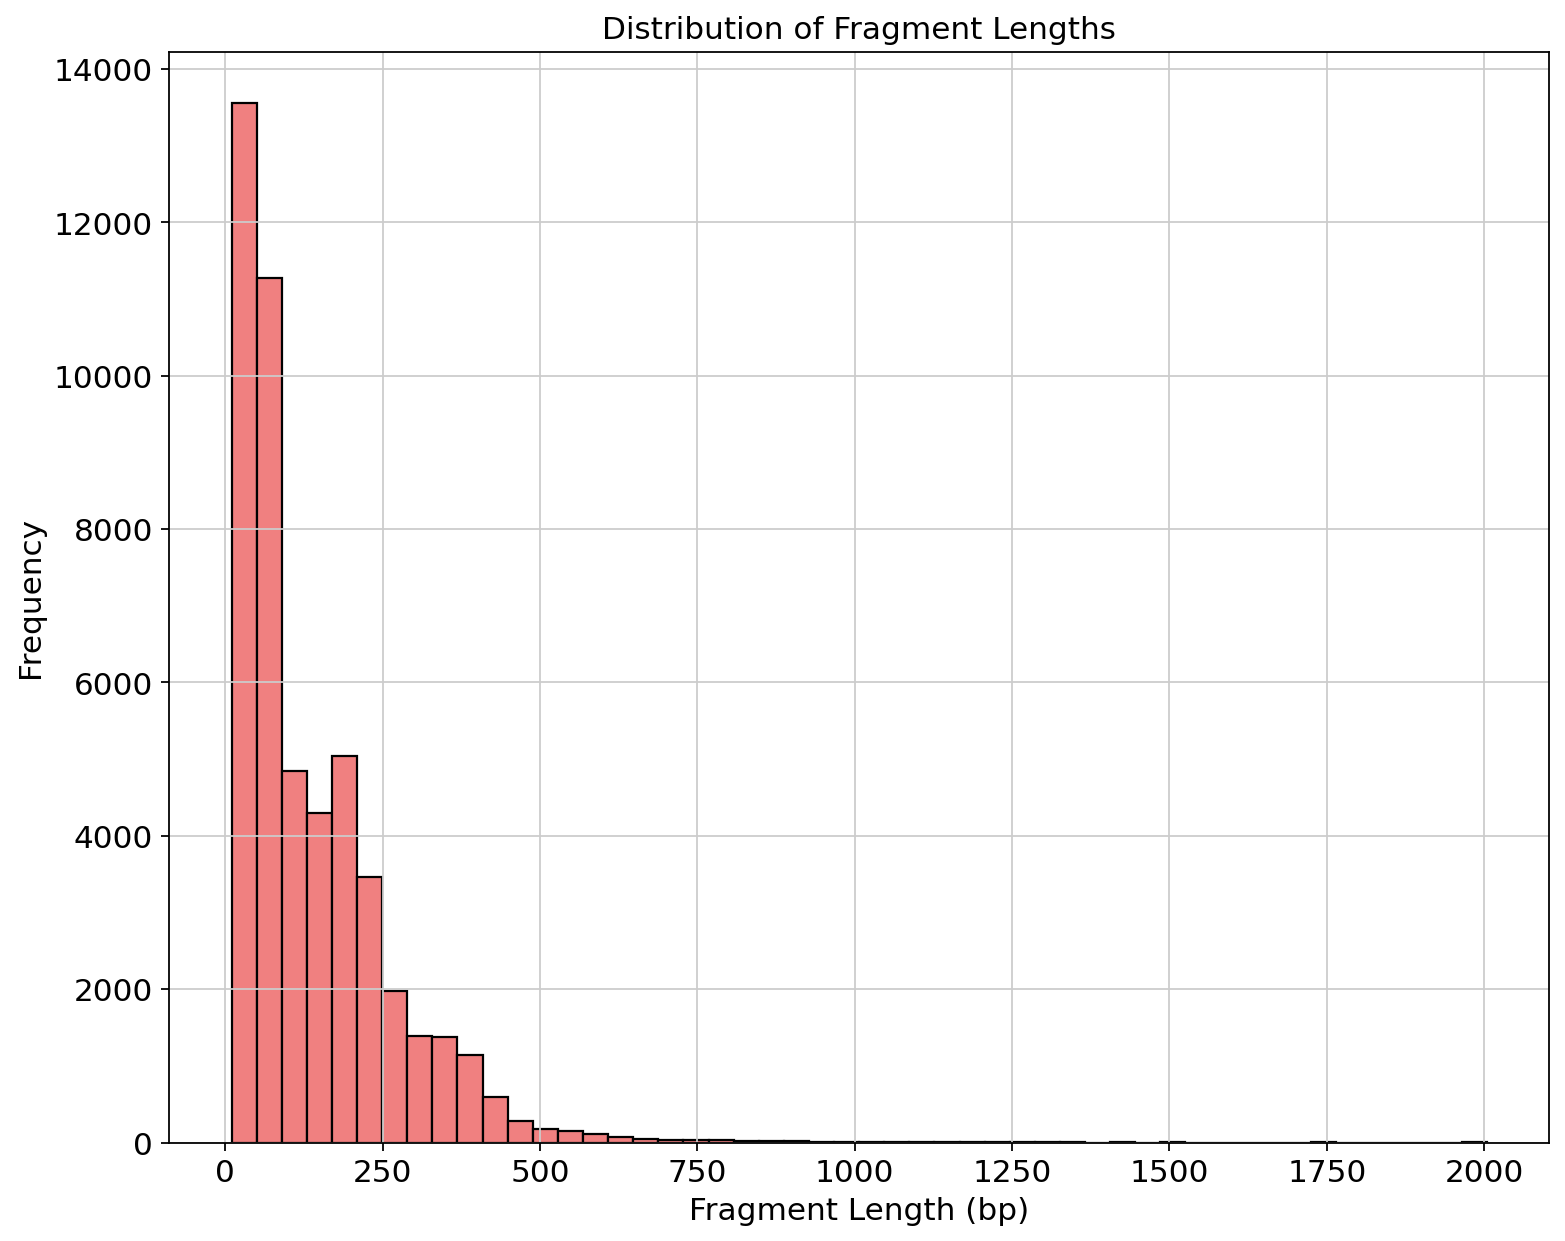

In [ ]:
# Implement your solution here
fig, ax = plt.subplots(figsize=(10, 8))
ax.hist(fragments["length"], bins=50, color="lightcoral", edgecolor="black")
ax.set_title("Distribution of Fragment Lengths")
ax.set_xlabel("Fragment Length (bp)")
ax.set_ylabel("Frequency")
plt.tight_layout()
plt.show()

In [ ]:
avg_fragment_length = fragments["length"].mean()
print(f"Average fragment length: {avg_fragment_length:.2f} bp")

Average fragment length: 138.53 bp


### Fraction of reads in peaks

Although we are working with the tile representation, it is still a good idea to check whether the reads aggregate in peaks across the genome. If not, we may have a low-quality library. Here, we will intersect peaks - called with the gold-standard tool MACS2 beforehand - with our tiles to quantify the enrichment of counts in peak regions - the fraction of reads in peaks (FRiP) score. Note that since we are looking at tile regions, we are making an approximation compared to ArchR that computes this statistic at the level of base pairs. Our next three steps are

<ol type="i">
  <li>Read peaks.</li>
  <li>Identify tiles overlapping peaks.</li>
  <li>Compute FRiP score for each cell.</li>
</ol>

<div style="padding: 10px; border-radius: 1px; width: 98%">
  <div style="background-color: rgb(83, 83, 83); color: white; padding: 10px; border-radius: 5px 5px 0 0; margin: -10px -10px 10px -10px">
    <b>Exercise 3.4</b>
  </div>
  Use <a href="https://daler.github.io/pybedtools/index.html">pybedtools</a> to read the BED file <i>peaks.bed</i> from <i>data/lab_3/processed/</i> as a BedTool object and save it in the variable <code>peaks</code>.
</div>

In [ ]:
# Implement your solution here
import pybedtools
peaks_df = pd.read_csv(f"{data_path}/peaks.bed", sep="\t")
peaks = pybedtools.BedTool.from_dataframe(peaks_df)
peaks


<BedTool(/tmp/pybedtools.7_dm1_9l.tmp)>

<div style="padding: 10px; border-radius: 1px; width: 98%">
  <div style="background-color: rgb(83, 83, 83); color: white; padding: 10px; border-radius: 5px 5px 0 0; margin: -10px -10px 10px -10px">
    <b>Exercise 3.5</b>
  </div>
  <ol type="a">
    <li>Convert <code>adata.var</code>, subsetted to the columns <code>chr</code>, <code>start</code>, and <code>end</code>, to a BedTool object named <code>tiles_bed</code>.</li>
    <li>Intersect <code>tiles_bed</code> with <code>peaks</code>, using the corresponding class method. Make sure to write the original entries in both objects for each overlap.</li>
    <li>Convert the resulting variable to a <a href="https://pandas.pydata.org/">pandas</a> DataFrame (<code>BedTools.to_dataframe</code>).</li>
    <li>Add a boolean column <code>overlaps_peak</code> that specifies if a tile in the data overlaps a peak to the appropriate AnnData entry.</li>
  </ol>
</div>

**Self-check:** The tiles overlap 121928 peaks.

<div style="padding: 10px; border-radius: 1px; width: 98%">
  <div style="background-color: rgb(114, 134, 86); color: white; padding: 10px; border-radius: 5px 5px 0 0; margin: -10px -10px 10px -10px">
    <b>Question 3.3</b>
  </div>
  What percentage of tiles overlap peaks? Round to two decimals.
</div>

In [ ]:
# Implement your solution here (3.5a-c)
tiles_bed = pybedtools.BedTool.from_dataframe(adata.var[["chr", "start", "end"]]) # converting tile coordinates from adata to bed files
tiles_bed_overlap = tiles_bed.intersect(peaks, wa=True, wb=True) # intersection of tiles and peaks keeping columns of both files
tiles_bed_overlap_df = tiles_bed_overlap.to_dataframe(names=["chr_tile", "start_tile", "end_tile", "chr_peak", "start_peak", "end_peak"]) # converting the intersection to a dataframe
n_tiles_overlap_unique_peaks = tiles_bed_overlap_df.drop_duplicates(subset=["chr_peak", "start_peak", "end_peak"]).shape[0] # dropping duplicate peaks since we want unique peaks to the same tiles
print(f"Number of tiles that overlap with peaks: {n_tiles_overlap_unique_peaks}")
tiles_bed_overlap_df.head()

Number of tiles that overlap with peaks: 121928


,chr_tile,start_tile,end_tile,chr_peak,start_peak,end_peak
0,chr1,752500,752999,chr1,752456,752956
1,chr1,800500,800999,chr1,800894,801394
2,chr1,801000,801499,chr1,800894,801394
3,chr1,805000,805499,chr1,805029,805529
4,chr1,805500,805999,chr1,805029,805529


In [ ]:
# Implement your solution here (3.5d)
adata.var["overlaps_peak"] = np.zeros(adata.var.shape[0], dtype=bool)

for index, row in tiles_bed_overlap_df.iterrows():
    tile_chr = row["chr_tile"]
    tile_start = row["start_tile"]
    tile_end = row["end_tile"]
    
    index = adata.var.index[(adata.var["chr"] == tile_chr) & (adata.var["start"] == tile_start) & (adata.var["end"] == tile_end)]

    adata.var.loc[index, "overlaps_peak"] = True

In [ ]:
percetange_tiles_overlap = adata.var["overlaps_peak"].mean()
print(f"Percentage of tiles that overlap with peaks: {percetange_tiles_overlap:.2%}")

Percentage of tiles that overlap with peaks: 88.84%


Having identified the tiles overlapping with peaks, we can compute the FRiP score: the fraction of fragments in tiles overlapping genes.

<div style="padding: 10px; border-radius: 1px; width: 98%">
  <div style="background-color: rgb(83, 83, 83); color: white; padding: 10px; border-radius: 5px 5px 0 0; margin: -10px -10px 10px -10px">
    <b>Exercise 3.5</b>
  </div>
  Compute the FRiP score and save it as a column <code>frip</code> in the appropriate AnnData entry.
</div>

<div style="padding: 10px; border-radius: 1px; width: 98%">
  <div style="background-color: rgb(114, 134, 86); color: white; padding: 10px; border-radius: 5px 5px 0 0; margin: -10px -10px 10px -10px">
    <b>Question 3.4</b>
  </div>

  What is the mean FRiP score? Round to 4 decimals.
  <blockquote></blockquote>
</div>

**Self-check:** The FRiP score for GSM3722071_Bone_Marrow_Rep1#ATGGATCGTGGTAAGC-1 is 0.748805.

In [ ]:
# Implement your solution here (frip : fraction of reads in peaks)
adata.obs["frip"] = adata.X.todense()[:, adata.var["overlaps_peak"]].sum(axis=1).A1 / adata.obs["fragments_per_cell"]
adata.obs["frip"].head()

print(f"The FRIP score for GSM3722071_Bone_Marrow_Rep1#ATGGATCGTGGTAAGC-1 is: {adata.obs.loc['GSM3722071_Bone_Marrow_Rep1#ATGGATCGTGGTAAGC-1', 'frip']:.6f}")
print(f"The mean FRIP score across all cells is: {adata.obs['frip'].mean():.4f}")

The FRIP score for GSM3722071_Bone_Marrow_Rep1#ATGGATCGTGGTAAGC-1 is: 0.748805
The mean FRIP score across all cells is: 0.6573


### QC visualization and filtering

Remember that we are already working with filtered data, so the distributions of our QC metrics will look fine, and we do not actually need to filter cells. In a real analysis, however, you will likely see lower modes for any of the QC metrics we have computed. In general, they are less likely to be skewed by cell size, so it is relatively safe to filter an entire lower mode using thresholds, as ArchR does. However, there are important cell-type specific factors that influence these values. While they will likely not cause problems at the filtering step, they are important to be aware of.

**Most importantly**: cells which are "less committed" (more stem-cell-like) often have a more globally accessible genome, and hence a larger number of fragments per cell. This will be a slightly more continuous shift in general - we will see an example of this below!

<div style="padding: 10px; border-radius: 1px; width: 98%">
  <div style="background-color: rgb(83, 83, 83); color: white; padding: 10px; border-radius: 5px 5px 0 0; margin: -10px -10px 10px -10px">
    <b>Exercise 3.6</b>
  </div>
  Visualize the histograms of the log1p-transformed fragments per cell and tile, and the FRiP score.
</div>

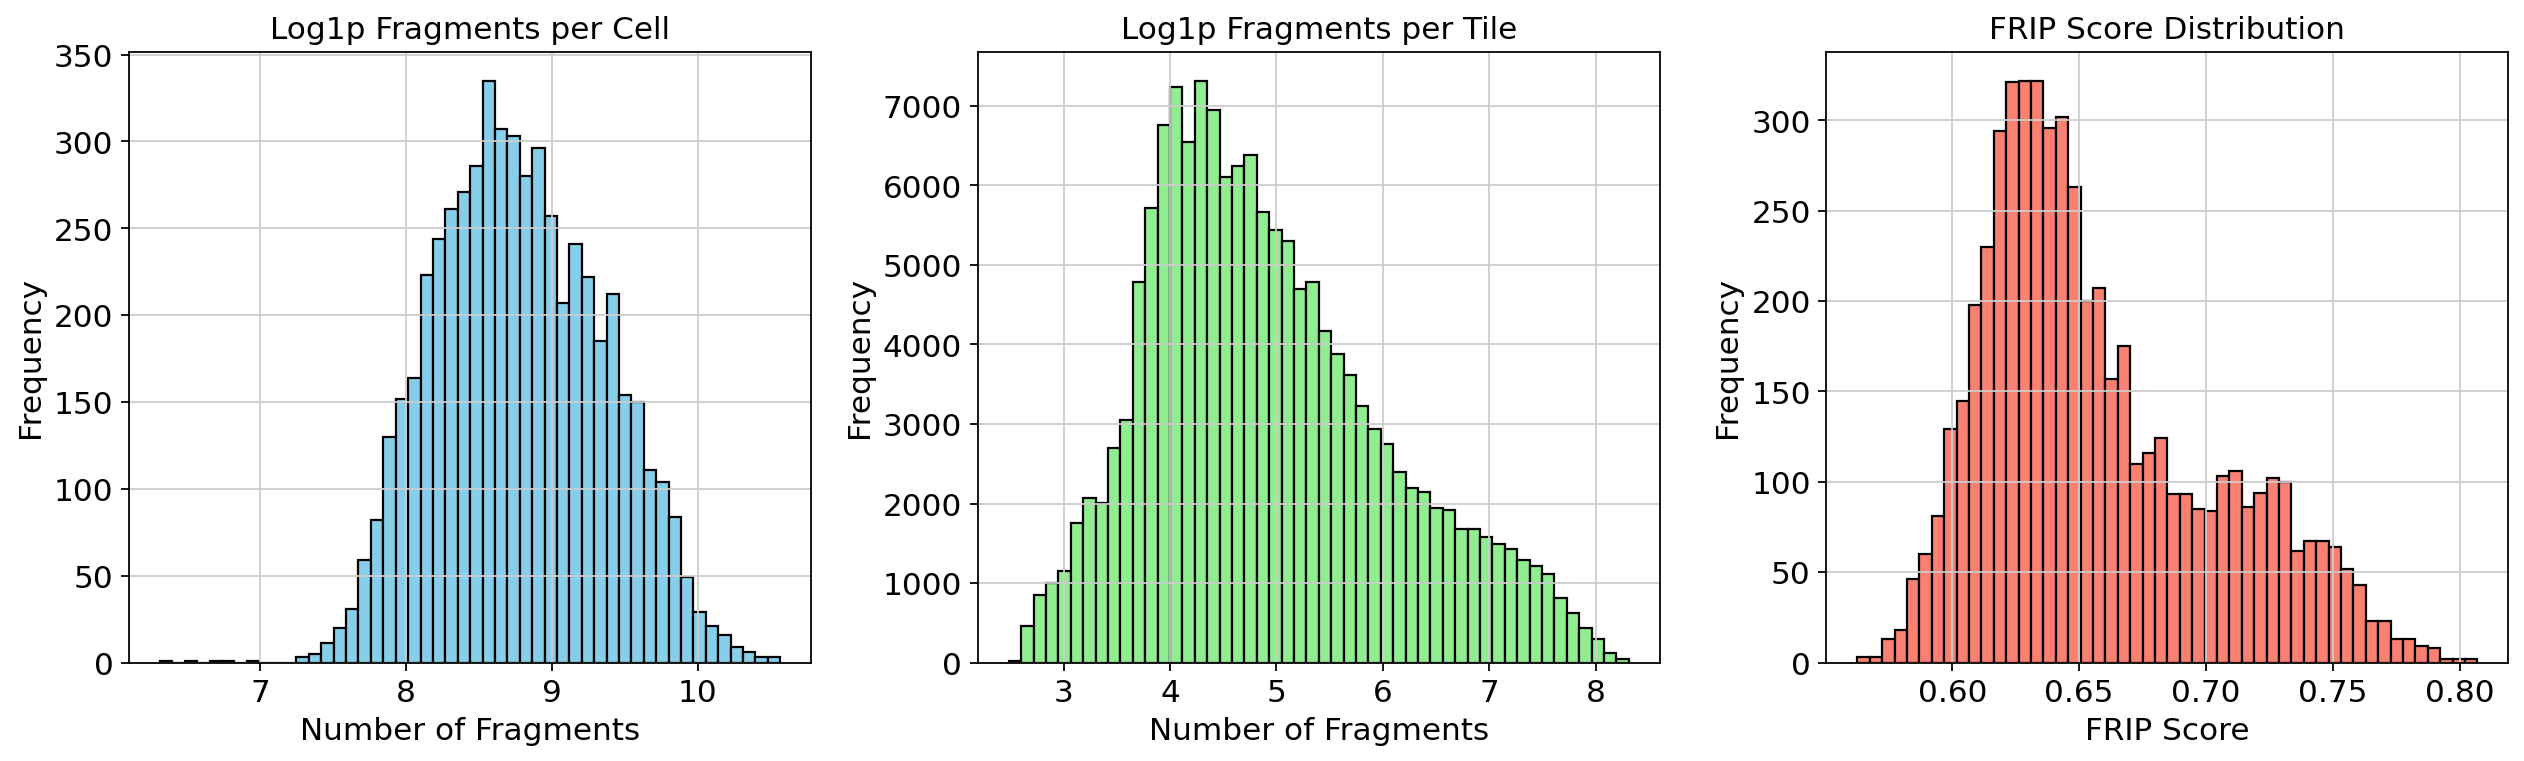

In [ ]:
# Implement your solution here
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
axes[0].hist(adata.obs["log1p_fragments_per_cell"], bins=50, color="skyblue", edgecolor="black")
axes[0].set_title("Log1p Fragments per Cell")
axes[0].set_xlabel("Number of Fragments")
axes[0].set_ylabel("Frequency")
axes[1].hist(adata.var["log1p_fragments_per_tile"], bins=50, color="lightgreen", edgecolor="black")
axes[1].set_title("Log1p Fragments per Tile")
axes[1].set_xlabel("Number of Fragments")
axes[1].set_ylabel("Frequency")
axes[2].hist(adata.obs["frip"], bins=50, color="salmon", edgecolor="black")
axes[2].set_title("FRIP Score Distribution")
axes[2].set_xlabel("FRIP Score")
axes[2].set_ylabel("Frequency")
plt.tight_layout()
plt.show()

## 4. Data normalization

So far, we have not controlled for library size, i.e., the number of fragments per cell here, but it is a feature shared between scATAC-seq and scRNA-seq data. Just as for scRNA-seq data, the per-cell capture rate is a technical feature which needs to be controlled for. In fact, we will proceed similar to median library size normalization, but with an additional step commonly used in the field of natural language processing (NLP). This normalization procedure - Term Frequency, Inverse Document Frequency (TF-IDF) normalization - works as follows:

1. **Compute the *term frequency*.** In NLP, the statistic refers to the frequency that each word appears in each document. Analogously, here, cells are documents and regions are words. Hence, the raw counts in our data matrix denote the appearance of a region (word) amongst the accessible regions in each cell (document); using binarized data as we do here is also a common choice in NLP. Since the frequencies are simply the counts normalized by the total number of regions captured in that cell, the concept is identical to library size normalization.

2. **Compute the *inverse document frequency*.** In NLP, this statistic refers to the inverse of the number of times each word appears across all documents, i.e., we are dividing out the total occurrence of that word, to down-weight the importance of particularly frequent words (such as "the"). Here, IDF will down-weight very ubiquitous peaks. Although we did not perform such a step in scRNA-seq analysis, it does relate to highly-variable gene selection as IDF can up-weight more variable regions.

3. **Compute TF-IDF.** The TF-IDF is given by the product of the term frequency and inverse document frequency.

<div style="padding: 10px; border-radius: 1px; width: 98%">
  <div style="background-color: rgb(83, 83, 83); color: white; padding: 10px; border-radius: 5px 5px 0 0; margin: -10px -10px 10px -10px">
    <b>Exercise 4.1</b>
  </div>
  <ol type="a">
    <li>Save the count matrix to <code>adata.layers</code>.</li>
    <li>Compute the frequency matrix and save it in <code>adata.X</code>.</li>
    <li>Compute the IDF and log IDF, and add them as columns <code>idf</code> and <code>log_idf</code>, respectively, to the appropriate AnnData attribute.</li>
    <li>Redefine  <code>adata.X</code> as the TF-IDF, using the log IDF values.</li>
  </ol>
</div>

**Self-check:** The mean IDF is 68.34975.

<div style="padding: 10px; border-radius: 1px; width: 98%">
  <div style="background-color: rgb(114, 134, 86); color: white; padding: 10px; border-radius: 5px 5px 0 0; margin: -10px -10px 10px -10px">
    <b>Question 4.1</b>
  </div>

  <ol type="a">
    <li>Which tile has the highest IDF?</li>
    <blockquote></blockquote>
    <li>How many local maxima does the distribution of log1p-transformed TF-IDF-normalized number of fragments per cell have? You may use a KDE plot to answer the question.</li>
    <blockquote></blockquote>
  </ol>
</div>

In [ ]:
# Implement your solution here
adata.layers["counts"] = adata.X.copy() # saving the original count data in a new layer before normalization

In [ ]:
frequency_matrix = adata.layers["counts"] / adata.obs["fragments_per_cell"].to_numpy().reshape(-1, 1) # normalizing the count data by the total number of fragments per cell
idf = adata.n_obs / adata.layers["counts"].sum(axis=0) # calculating the inverse document frequency for each tile
log_idf = np.log1p(idf) # applying log transformation to the idf values
adata.var["idf"] = idf.A1
adata.var["log_idf"] = log_idf.A1
tf_idf_matrix = frequency_matrix.multiply(log_idf) # calculating the TF-IDF matrix by multiplying the frequency matrix with the log-transformed idf values
adata.X = tf_idf_matrix.tocsr() # converting the TF-IDF matrix back to sparse format for efficient storage and computation
print(f"Mean of IDF is {adata.var['idf'].mean():.5f}")

Mean of IDF is 68.34975


In [ ]:
# Implement your solution here ()
tile_highest_idf = adata.var.loc[adata.var["idf"].idxmax()]
print(f"Tile with the highest IDF value: {tile_highest_idf.name}")

Tile with the highest IDF value: chr10_117658000


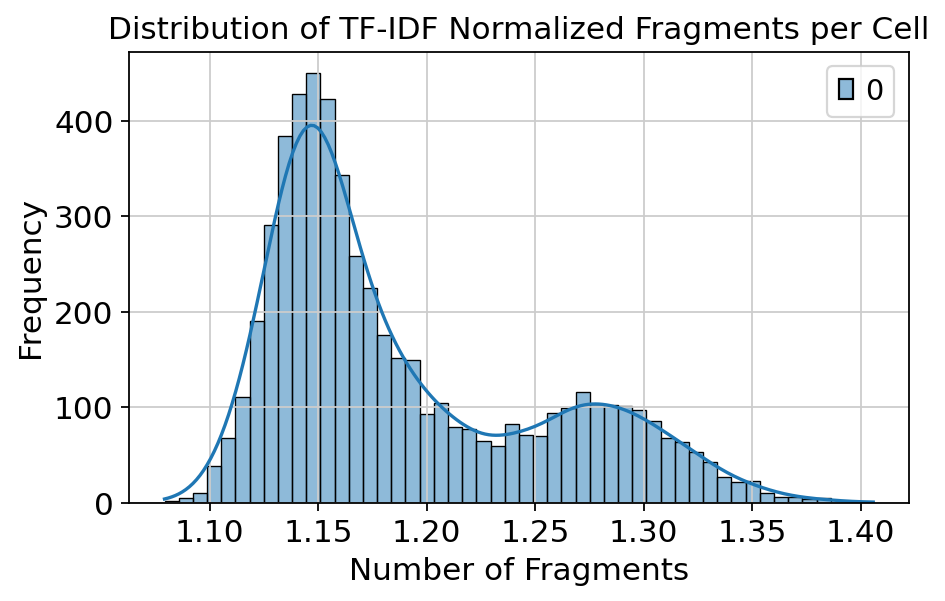

In [97]:
import seaborn as sns
fig, ax = plt.subplots(figsize=(6, 4))
sns.histplot(np.log1p(tf_idf_matrix.sum(axis=1)), bins=50, color="lightblue", edgecolor="black", kde=True, ax=ax)
ax.set_title("Distribution of TF-IDF Normalized Fragments per Cell")
ax.set_xlabel("Number of Fragments")
ax.set_ylabel("Frequency")
plt.tight_layout()
plt.show()

# 5. Gene scoring

So far, we have no way of annotating our cells to visualize their distributions in accessibility space. For interpretation and annotation, we usually want to get a sense of which genes are active in each cells, but our tile variables do not directly provide this information. Luckily, chromatin accessibility (especially near the promoter) tends to correlate well with expression of nearby genes. As such, we can use a summary statistic of the accessibility in the viscinity of each gene to estimate expressed genes. For the sake of time, our data already includes such a summary statistic, namely *gene scores*, pre-computed with from ArchR.

Briefly, ArchR computes the gene score representation by taking a weighted average of accessibility counts around the transcription start site (TSS) of each gene. The weight is highest right at the TSS, meaning the accessibility here most strongly impacts the score, and decays as you you get further and further away. In general, the further we are from the gene promoter, the less confident we are that any given cis-regulatory element is actually associating with that gene; in fact, even nearby enhancers can sometime regulate a different gene, thanks to looping of the DNA to bring far-away chromatin nearby. Still, this score is usually a good enough approximation, especially for the purpose of annotation and when using multiple genes to achieve that end.

<img src="https://www.archrproject.com/bookdown/images/GeneActivityScore_Schematic.png" alt="genescore" width="500">

## 6. Dimensionality reduction

Following data normaliztion, we reduced the dimensionality of our scRNA-seq data in the previous labs. In NLP, normalization and dimensionality reduction are a single step - the **latent semantic indexing** (LSI). LSI is very similar to PCA - a canonical choice for scRNA-seq data - as it employs singular value decomposition (SVD) - the method normally used to perform PCA. SVD takes the cell by tile matrix $X$ as input and decomposes it into a product of three component matrices: a column-orthonormal matrix $U$ of dimension $n_{\text{c}} \times k$, a row-orthonormal matrix $V$ of dimension $n_{\text{t} \times k}$, and a $k \times k$ dimensional diagonal matrix $\Sigma$ with singular values on the diagonal, where $n_{\text{c}}$ denotes the number of cells, $n_{\text{t}}$ the number of tiles, and $k$ the number of singular values to consider (larger $k$ correspond to more accurate reconstruction).

$$X = U \Sigma V^T$$

<div style="padding: 10px; border-radius: 1px; width: 98%">
  <div style="background-color: rgb(83, 83, 83); color: white; padding: 10px; border-radius: 5px 5px 0 0; margin: -10px -10px 10px -10px">
    <b>Exercise 6.1</b>
  </div>
  <ol type="a">
    <li>Use scipy to compute the partial SVD of the sparse TF-IDF data matrix for 30 topics (singular values).</li>
    <li>Define the LSI representation as the matrix U, with columns scaled by the singular values, and add it to the appropriate AnnData attribute (keyword <code>lsi</code>).</li>
  </ol>
</div>

In [ ]:
# Implement your solution here
from scipy.sparse.linalg import svds
u, s, vh = svds(adata.X, k=30) # performing SVD on the TF-IDF matrix to reduce dimensionality to 30 components
lsi_embedding = u * s # calculating the LSI embedding by multiplying the left singular vectors with the singular values (scaled by singular values)
adata.obsm['lsi'] = lsi_embedding

Having a latent representation of our cells, we can proceed as before with the PCA embedding for scRNA-seq data to visualize our data in two dimensions.

<div style="padding: 10px; border-radius: 1px; width: 98%">
  <div style="background-color: rgb(83, 83, 83); color: white; padding: 10px; border-radius: 5px 5px 0 0; margin: -10px -10px 10px -10px">
    <b>Exercise 6.2</b>
  </div>
  <ol type="a">
    <li>Use scanpy to compute a neighbor graph based on the LSI representation.</li>
    <li>Use scanpy to compute and visualize the UMAP embedding. Color the embedding by the log1p-transformed number of fragments per cell.</li>
  </ol>
</div>

computing neighbors
    finished (0:00:00)
computing UMAP
    finished (0:00:11)


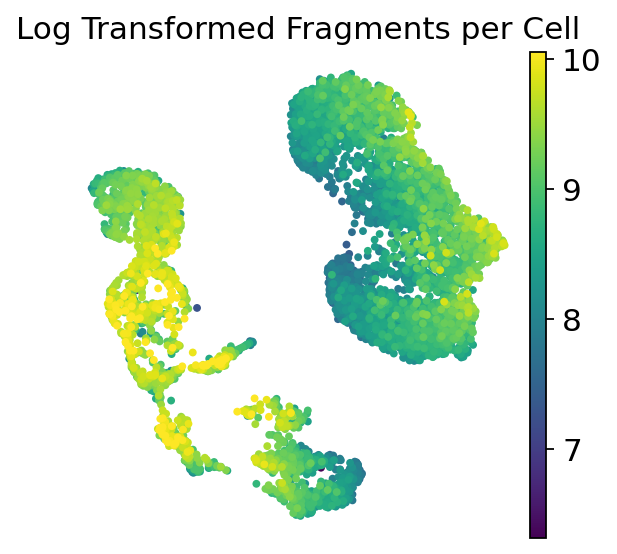

In [ ]:
# Implement your solution here
sc.pp.neighbors(adata, use_rep='lsi') # computing the neighborhood graph using the LSI embedding
sc.tl.umap(adata) # computing the UMAP embedding for visualization
sc.pl.umap(adata, color="log1p_fragments_per_cell", cmap="viridis", vmax="p99", s=50, title="Log Transformed Fragments per Cell") # visualization

We can also color the UMAP embedding to get a feeling for which cells correspond to which cell type.

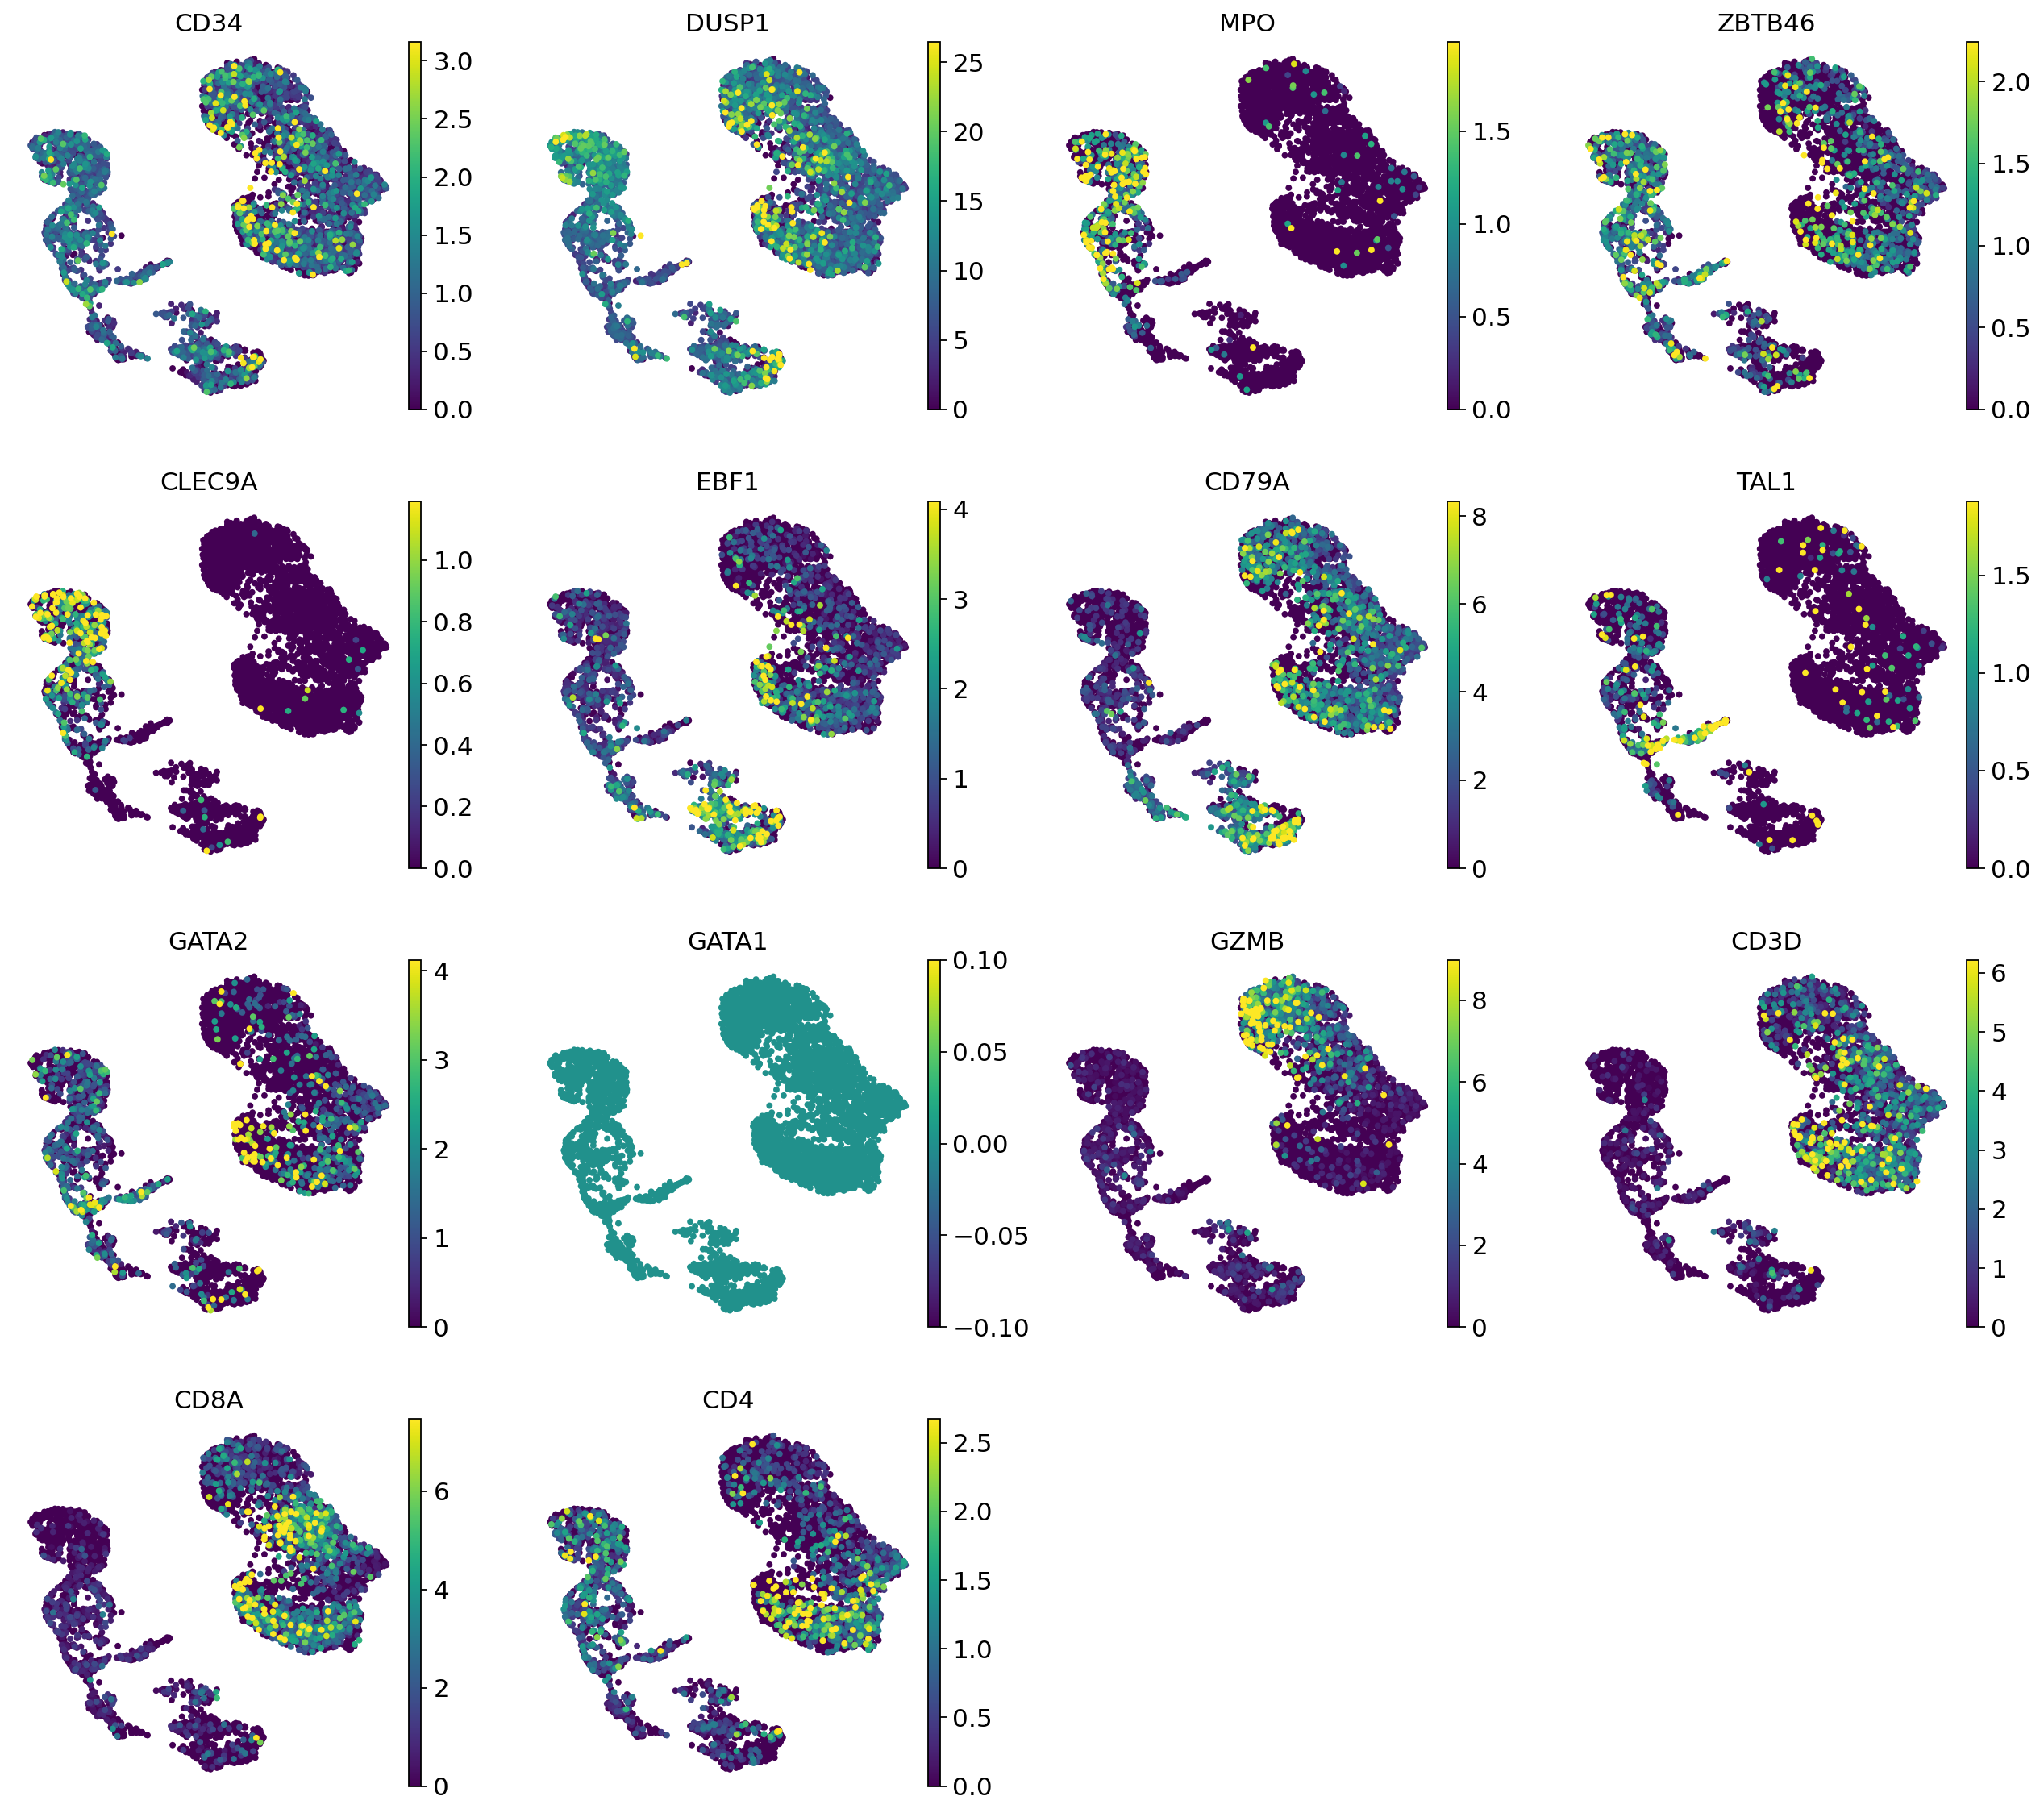

In [ ]:
# stem cells: CD34, DUSP1
# monocyte precursor: MPO
# dendritic cells: ZBTB46", "CLEC9A"
# common lymphoid progenitors: EBF1, CD79A
# erythroid: TAL1, GATA1, GATA2
# non-stem cell: GZMB, CD3D, CD8A, CD4
markers = [
    "CD34",
    "DUSP1",
    "MPO",
    "ZBTB46",
    "CLEC9A",
    "EBF1",
    "CD79A",
    "TAL1",
    "GATA2",
    "GATA1",
    "GZMB",
    "CD3D",
    "CD8A",
    "CD4",
]

adata.obs[markers] = adata.obsm["gene_score"][markers]
sc.pl.embedding(adata, basis="umap", color=markers, vmin="p1", vmax="p99", s=50)
plt.show()

adata.obs = adata.obs.drop(columns=markers)

## 7. Pseudobulking over metacells

Our results so far highlight how sparse and noisy scATAC-seq data is - even more so than scRNA-seq data! To mitigate this effect, we can combine information across highly similar cells, defining so-called *metacells*. First introduced by <a href="https://link.springer.com/article/10.1186/s13059-019-1812-2">Baran et al.</a>, metacells reduce data sparsity and improve interpretability. Intuitively, *metacells* can be thought of as a clustering of our data at super high resoluton, where each cluster combines on the order of 20-100 cells into one *metacell*. Our following analysis uses metacell assignments, pre-computed with <a href="https://www.nature.com/articles/s41587-023-01716-9">SEACells</a>, to pseudobulk over them and re-compute embeddings; the columns `metacell_assignment` and `metacell_center` assign each cell to a metacell and specify whether or not a cell is the center of a metacell, respectively.

<div style="padding: 10px; border-radius: 1px; width: 98%">
  <div style="background-color: rgb(83, 83, 83); color: white; padding: 10px; border-radius: 5px 5px 0 0; margin: -10px -10px 10px -10px">
    <b>Exercise 7.1</b>
  </div>
  Visualize the scATAC-based UMAP embedding and, additionally, plot the metacell centers on top.
</div>

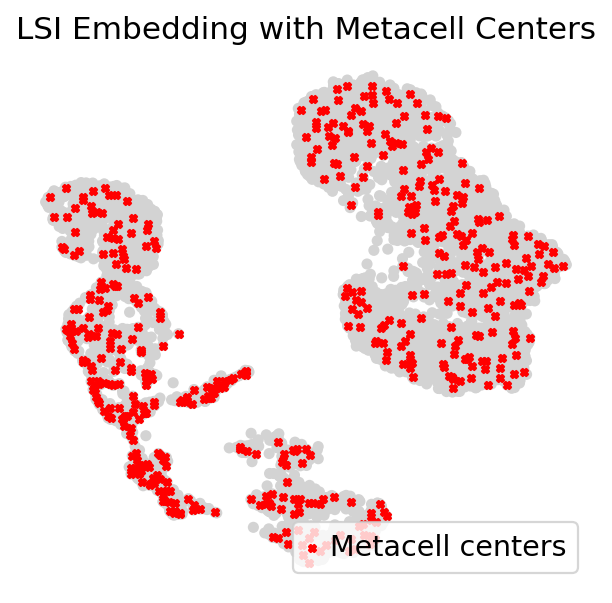

In [ ]:
# Implement your solution here
ax = sc.pl.umap(adata, s=100, title="LSI Embedding with Metacell Centers", show=False)

# Get the coordinates of metacell centers
metacell_centers = adata[adata.obs["metacell_center"]].obsm["X_umap"]

# Plot metacell centers on top
plt.scatter(metacell_centers[:, 0], metacell_centers[:, 1], 
            s=10, marker='X', c='red', 
            label='Metacell centers')

plt.legend(loc='lower right')
plt.tight_layout()

<div style="padding: 10px; border-radius: 1px; width: 98%">
  <div style="background-color: rgb(83, 83, 83); color: white; padding: 10px; border-radius: 5px 5px 0 0; margin: -10px -10px 10px -10px">
    <b>Exercise 7.2</b>
  </div>
  Pseudobulk the scATAC counts by summing the counts of each metacell to define a new AnnData object <code>metacell_adata</code>. Make sure to save the data in sparse CSR format.
</div>

In [ ]:
# Implement your solution here
# Implementation with scipy sparse matrix operations for efficient pseudobulk count matrix creation
import scipy.sparse as sp
import anndata as ad

# Define metacell labels
metacell_labels = adata.obs["metacell_assignment"].astype("category")
codes = metacell_labels.cat.codes.values          # integer index per cell
metacells = metacell_labels.cat.categories

# Build indicator matrix (n_metacells, n_cells) where entry (i, j) is 1 if cell j belongs to metacell i, else 0
indicator = sp.csr_matrix(
    (np.ones(adata.n_obs), (codes, np.arange(adata.n_obs))),
    shape=(len(metacells), adata.n_obs)
)

# Compute pseudobulk count matrix by multiplying the indicator matrix with the original count matrix (adata.layers["counts"]) (n_metacells, n_tiles)
X_pb = indicator @ adata.layers["counts"]                        # stays sparse automatically

# Build new AnnData
metacell_adata = ad.AnnData(
    X=X_pb,
    obs=pd.DataFrame(index=metacells),
    var=adata.var.copy(),
)


<div style="padding: 10px; border-radius: 1px; width: 98%">
  <div style="background-color: rgb(83, 83, 83); color: white; padding: 10px; border-radius: 5px 5px 0 0; margin: -10px -10px 10px -10px">
    <b>Exercise 7.3</b>
  </div>
  <ol type="a">
    <li>Add the number of fragments per metacell along with their log1p transformation as columns <code>n_fragments</code> and <code>n_fragments</code> to <code>metacell_adata</code>.</li>
    <li>Visualize the distribution of the scATAC-based and metacell-based log1p-transformed statistics.</li>
</div>

<div style="padding: 10px; border-radius: 1px; width: 98%">
  <div style="background-color: rgb(114, 134, 86); color: white; padding: 10px; border-radius: 5px 5px 0 0; margin: -10px -10px 10px -10px">
    <b>Question 7.1</b>
  </div>

  On average, what is the fold change between the metacell-based and scATAC-seq-based number of fragments per observation?
</div>

In [111]:
# Implement your solution here
fragments_per_metacell = metacell_adata.X.sum(axis=1).A1
log1p_fragments_per_metacell = np.log1p(fragments_per_metacell)
metacell_adata.obs["n_fragments"] = fragments_per_metacell
metacell_adata.obs["log1p_n_fragments"] = log1p_fragments_per_metacell

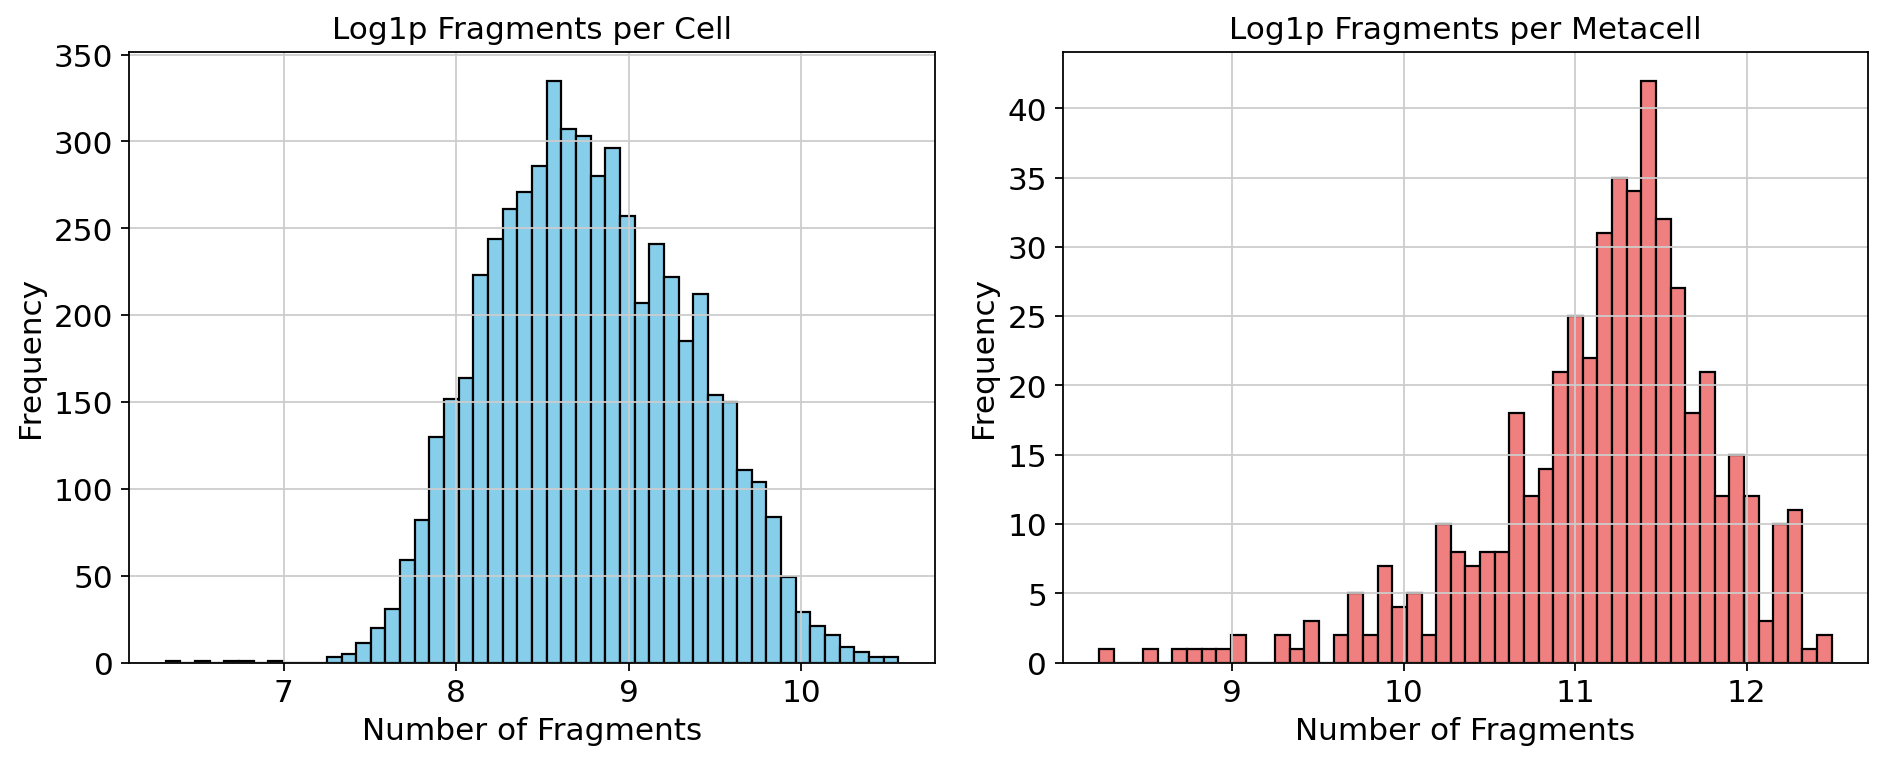

In [112]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].hist(adata.obs["log1p_fragments_per_cell"], bins=50, color="skyblue", edgecolor="black")
axes[0].set_title("Log1p Fragments per Cell")
axes[0].set_xlabel("Number of Fragments")
axes[0].set_ylabel("Frequency")
axes[1].hist(metacell_adata.obs["log1p_n_fragments"], bins=50, color="lightcoral", edgecolor="black")
axes[1].set_title("Log1p Fragments per Metacell")
axes[1].set_xlabel("Number of Fragments")
axes[1].set_ylabel("Frequency")
plt.tight_layout()
plt.show()


In [131]:
fold_change_average = metacell_adata.obs["n_fragments"].mean() / adata.obs["fragments_per_cell"].mean()
print(f"Average fold change in number of fragments per metacell compared to per cell: {fold_change_average:.2f}x")

Average fold change in number of fragments per metacell compared to per cell: 11.06x


<div style="padding: 10px; border-radius: 1px; width: 98%">
  <div style="background-color: rgb(83, 83, 83); color: white; padding: 10px; border-radius: 5px 5px 0 0; margin: -10px -10px 10px -10px">
    <b>Exercise 7.4</b>
  </div>
  <ol type="a">
    <li>Add the metacell counts as a layer <code>counts</code>.</li>
    <li>Update <code>metacell_adata.X</code> by the pseudobulked single-cell TF-IDF values (remember to use the appropriate data format!).</li>
    <li>Add the pseudobulked gene scores to <code>metacell_adata.X</code>.</li>
</div>

In [113]:
# Implement your solution here
metacell_adata.layers["counts"] = metacell_adata.X.copy() # saving the original count data in a new layer before normalization

In [128]:
# Update metacell_adata.X with pseudobulk TF-IDF normalized values
metacell_adata.X = indicator @ adata.X # pseudobulking tf-idf normalized values from adata to metacell_adata
metacell_adata.obsm["gene_score"] = pd.DataFrame(indicator @ adata.obsm["gene_score"], columns=adata.obsm["gene_score"].columns, index=metacell_adata.obs.index) # pseudobulking gene scores from adata to metacell_adata

In [117]:
metacell_adata

AnnData object with n_obs × n_vars = 500 × 150000
    obs: 'n_fragments', 'log1p_n_fragments'
    var: 'chr', 'start', 'end', 'fragments_per_tile', 'log1p_fragments_per_tile', 'overlaps_peak', 'idf', 'log_idf'
    obsm: 'gene_score'
    layers: 'counts'

Just as with our single-cell data, we want to compute low-dimensional representations of our metacell data.

<div style="padding: 10px; border-radius: 1px; width: 98%">
  <div style="background-color: rgb(83, 83, 83); color: white; padding: 10px; border-radius: 5px 5px 0 0; margin: -10px -10px 10px -10px">
    <b>Exercise 7.5</b>
  </div>
  <ol type="a">
    <li>Compute the metacell-based LSI embedding and add it to <code>metacell_adata</code>, using the same parameters as before.</li>
    <li>Compute the nearest neighbor graph on the LSI embedding.</li>
    <li>Compute the UMAP embedding of the metacells.</li>
</div>

In [118]:
# Implement your solution here
metacell_u, metacell_s, metacell_vh = svds(metacell_adata.X, k=30) # performing SVD on the TF-IDF matrix to reduce dimensionality to 30 components
metacell_lsi_embedding = metacell_u * metacell_s # calculating the LSI embedding by multiplying the left singular vectors with the singular values (scaled by singular values)
metacell_adata.obsm['lsi'] = metacell_lsi_embedding

In [119]:
# Implement your solution here
sc.pp.neighbors(metacell_adata, use_rep='lsi') # computing the neighborhood graph using the LSI embedding
sc.tl.umap(metacell_adata) # computing the UMAP embedding for visualization

computing neighbors
    finished (0:00:00)
computing UMAP
    finished (0:00:00)


<div style="padding: 10px; border-radius: 1px; width: 98%">
  <div style="background-color: rgb(83, 83, 83); color: white; padding: 10px; border-radius: 5px 5px 0 0; margin: -10px -10px 10px -10px">
    <b>Exercise 7.6</b>
  </div>
  Visualize the UMAP embedding, colored by the markers defined above.
</div>

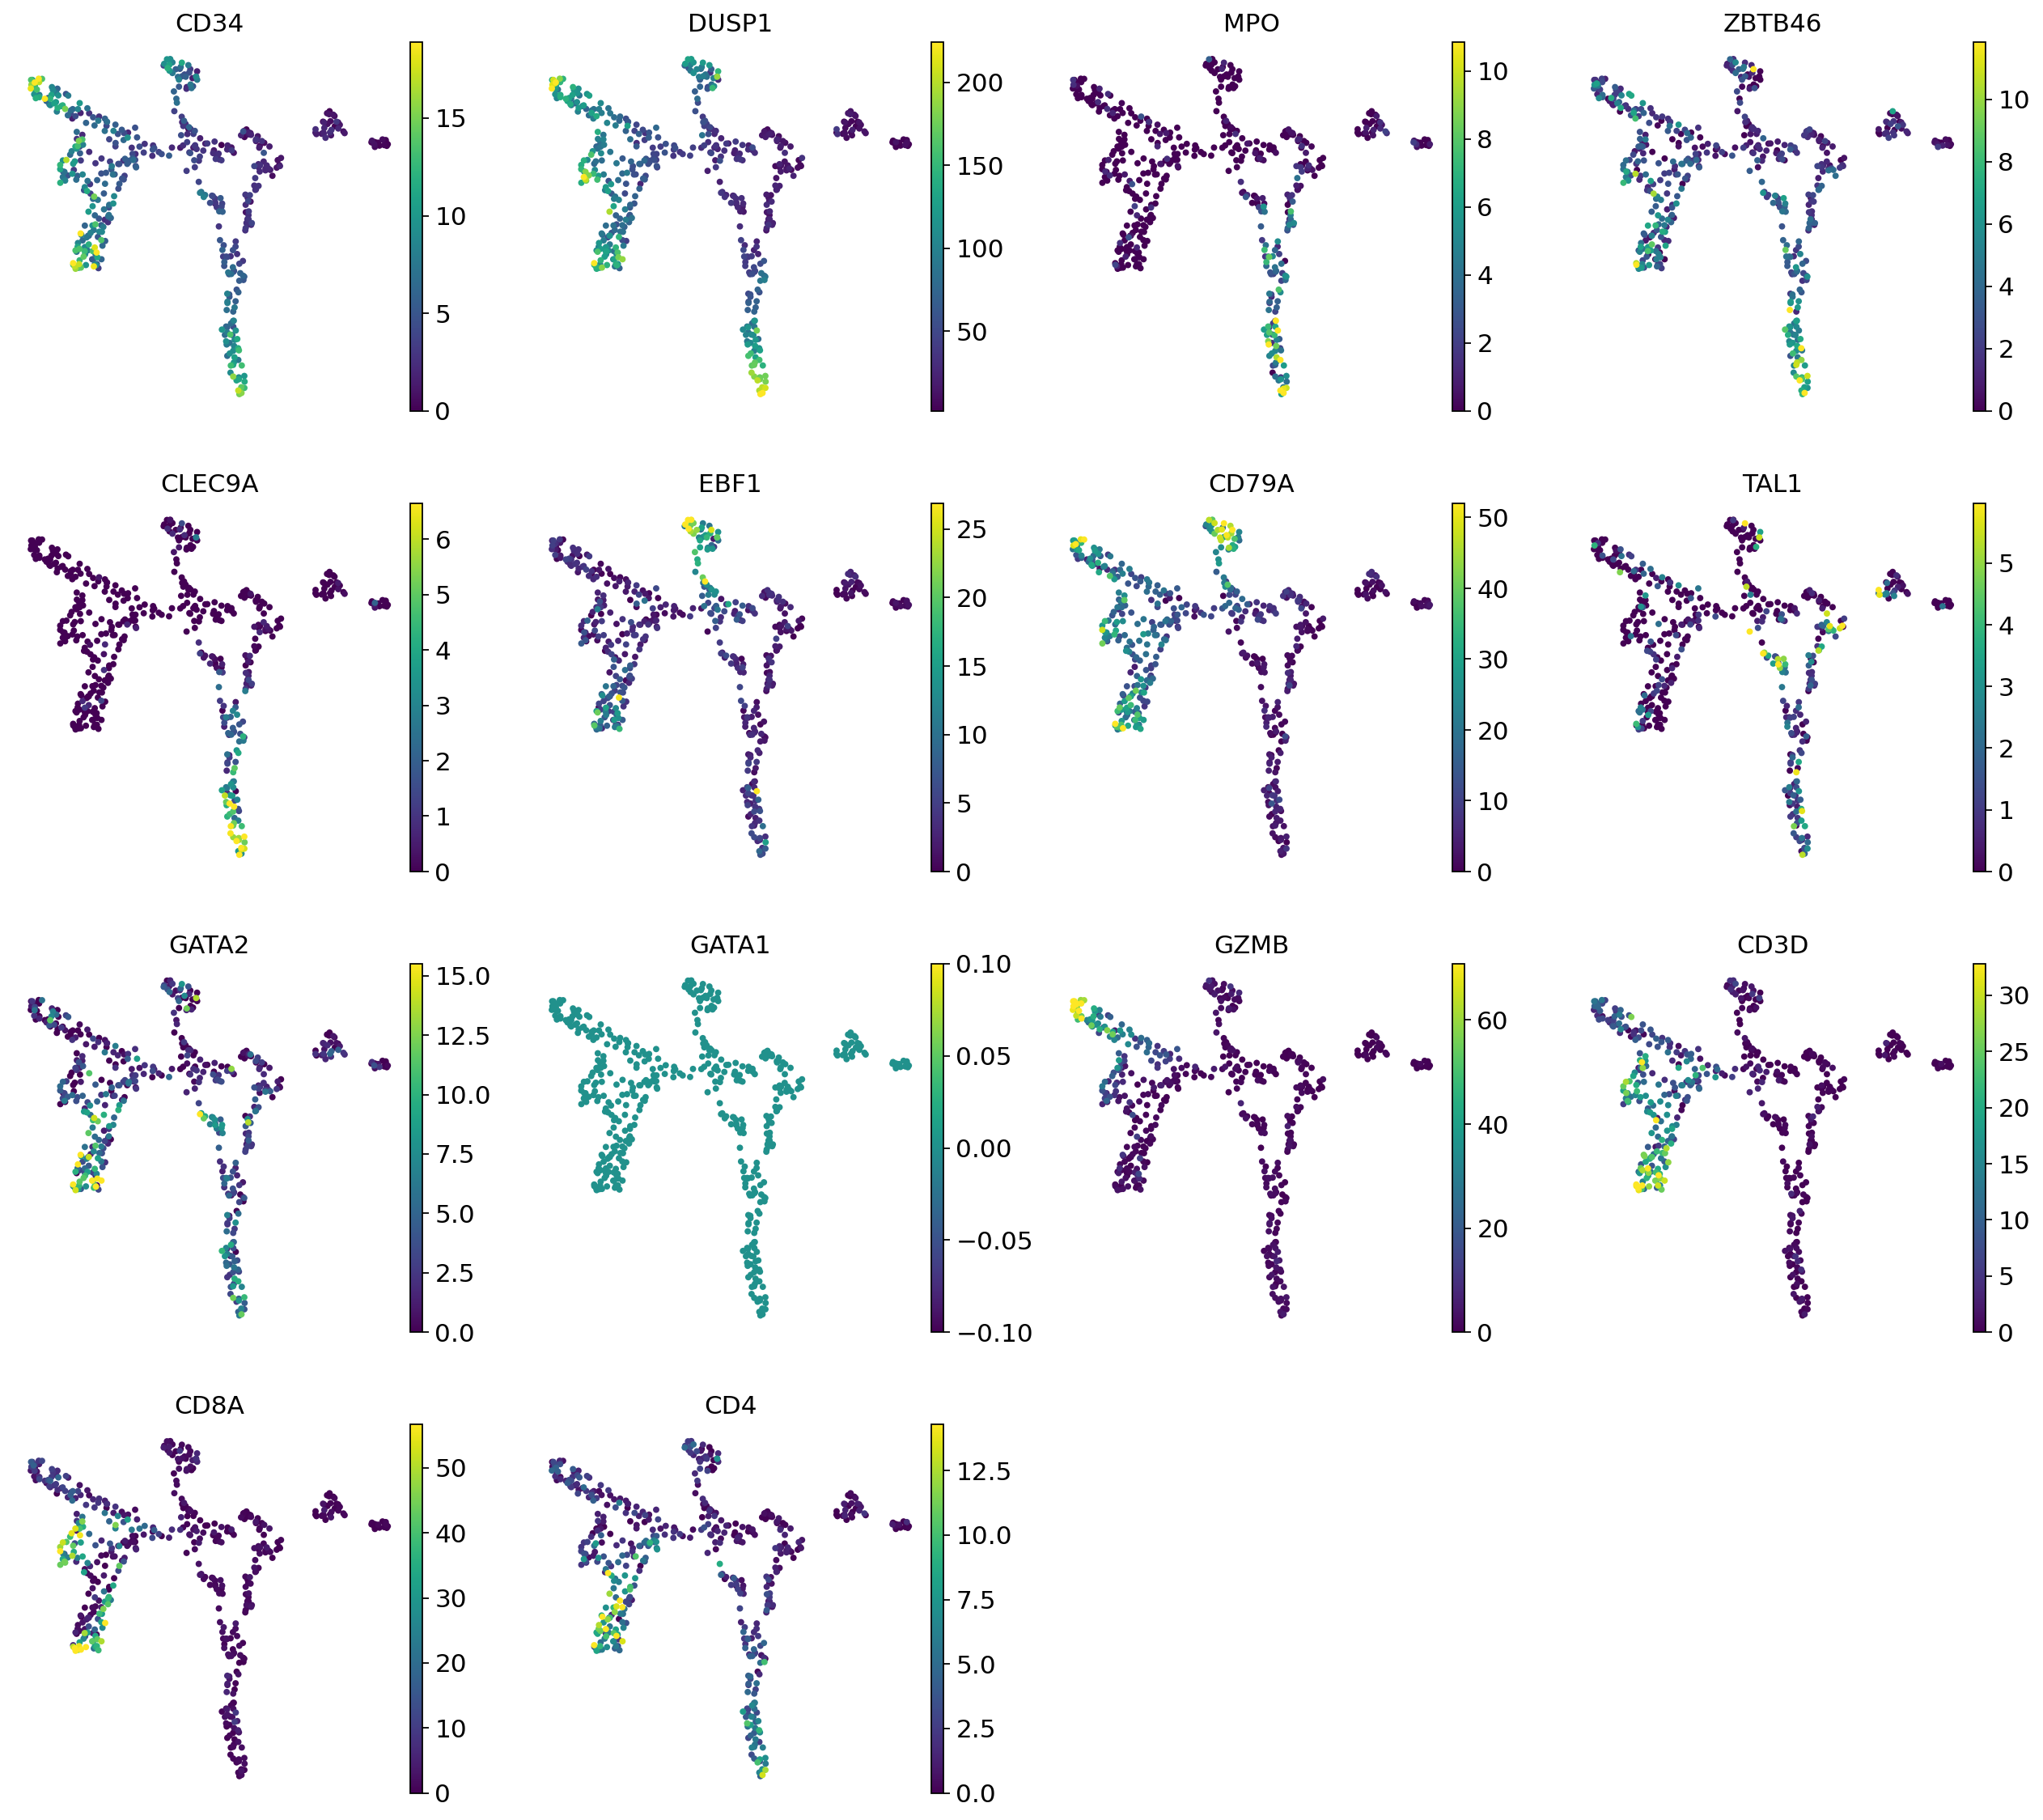

In [130]:
# Implement your solution here
metacell_adata.obs[markers] = metacell_adata.obsm["gene_score"][markers]
sc.pl.embedding(metacell_adata, basis="umap", color=markers, vmin="p1", vmax="p99", s=50)
plt.show()

We see that by aggregating our data into metacells, we could mitigate noise and sparsity enough to recover more structure and crisper signal in our data!